In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/README.md
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_p_3.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_f_1.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_p_1.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_p_2.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_f_3.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Asharp3/Asharp3_f_2.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Fsharp5/Fsharp5_p_1.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Fsharp5/Fsharp5_f_2.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Fsharp5/Fsharp5_p_2.wav
/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune/intune/Fsharp5/Fsharp5_f_1.wa

# Guitar Notes Dataset Visualization

This notebook explores the attached `intune` and `detune` guitar note audio folders. It inspects dataset structure, visualizes waveforms and spectrograms, extracts MFCC features, and compares audio statistics between tuned and detuned recordings.

## 1. Import Libraries and Configure Paths

In [4]:
import os
from pathlib import Path
import glob
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

base_dir = Path('/kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune')
intune_dir = base_dir / 'intune'
detune_dir = base_dir / 'detune'

print('Base directory:', base_dir.resolve())
print('Intune folder exists:', intune_dir.exists())
print('Detune folder exists:', detune_dir.exists())

Base directory: /kaggle/input/datasets/heysiri0/acoustic-guitar-intune-detune
Intune folder exists: True
Detune folder exists: True


## 2. Inspect Dataset Structure and Counts

In [5]:
def collect_note_files(root_dir):
    root_dir = Path(root_dir)
    records = []
    if not root_dir.exists():
        return pd.DataFrame(records)

    for note_folder in sorted([p for p in root_dir.iterdir() if p.is_dir()]):
        wav_files = sorted(note_folder.glob('*.wav'))
        for wav_path in wav_files:
            records.append({
                'root': str(root_dir.name),
                'note_folder': note_folder.name,
                'file_name': wav_path.name,
                'path': str(wav_path)
            })
    return pd.DataFrame(records)

intune_files = collect_note_files(intune_dir)
detune_files = collect_note_files(detune_dir)

intune_summary = intune_files.groupby('note_folder').size().reset_index(name='count').sort_values('note_folder')
detune_summary = detune_files.groupby('note_folder').size().reset_index(name='count').sort_values('note_folder')

print('Number of intune note folders:', intune_summary.shape[0])
print('Number of detune note folders:', detune_summary.shape[0])
print('Total intune files:', len(intune_files))
print('Total detune files:', len(detune_files))

display(intune_summary.head(15))
display(detune_summary.head(15))

Number of intune note folders: 43
Number of detune note folders: 43
Total intune files: 243
Total detune files: 243


,note_folder,count
0,A2,4
1,A3,6
2,A4,6
3,Asharp2,5
4,Asharp3,6
5,Asharp4,6
6,B2,4
7,B3,8
8,B4,6
9,C3,4


,note_folder,count
0,A2,4
1,A3,6
2,A4,6
3,Asharp2,5
4,Asharp3,6
5,Asharp4,6
6,B2,4
7,B3,8
8,B4,6
9,C3,4


## 2.5 Metadata Extraction

In [6]:
def parse_file_name(file_name):
    stem = Path(file_name).stem
    parts = stem.split()
    if len(parts) == 3:
        note_label, technique, instance = parts
    else:
        note_label, technique, instance = parts[0], None, None
    return pd.Series({
        'file_note': note_label,
        'technique': technique,
        'instance': instance
    })

for df in [intune_files, detune_files]:
    df[['file_note', 'technique', 'instance']] = df['file_name'].apply(parse_file_name)

print('Intune file metadata sample:')
display(intune_files[['note_folder', 'file_name', 'file_note', 'technique', 'instance']].head())
print('Detune file metadata sample:')
display(detune_files[['note_folder', 'file_name', 'file_note', 'technique', 'instance']].head())

for root_name, df in [('intune', intune_files), ('detune', detune_files)]:
    print(f'{root_name} technique counts:')
    print(df['technique'].value_counts())
    print()

Intune file metadata sample:


,note_folder,file_name,file_note,technique,instance
0,A2,A2_f_1.wav,A2_f_1,None,None
1,A2,A2_f_2.wav,A2_f_2,None,None
2,A2,A2_p_1.wav,A2_p_1,None,None
3,A2,A2_p_2.wav,A2_p_2,None,None
4,A3,A3_f_1.wav,A3_f_1,None,None


Detune file metadata sample:


,note_folder,file_name,file_note,technique,instance
0,A2,detuned_A2_f_1.wav,detuned_A2_f_1,None,None
1,A2,detuned_A2_f_2.wav,detuned_A2_f_2,None,None
2,A2,detuned_A2_p_1.wav,detuned_A2_p_1,None,None
3,A2,detuned_A2_p_2.wav,detuned_A2_p_2,None,None
4,A3,detuned_A3_f_1.wav,detuned_A3_f_1,None,None


intune technique counts:
Series([], Name: count, dtype: int64)

detune technique counts:
Series([], Name: count, dtype: int64)



## 3. Load Audio Files and Visualize Waveforms

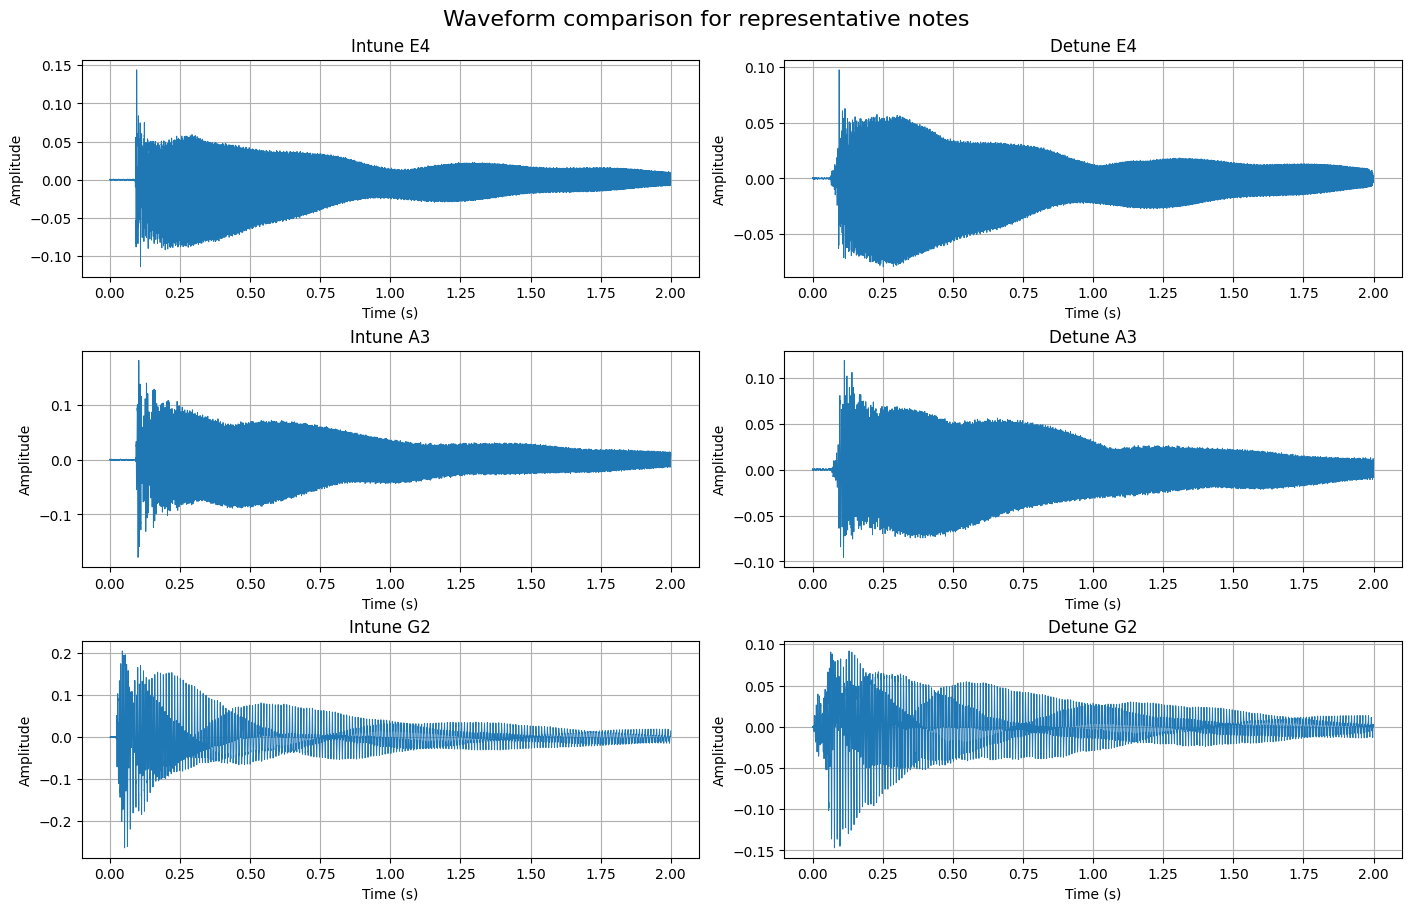

In [7]:
def load_audio(path, sr=None):
    signal, sample_rate = librosa.load(path, sr=sr, mono=True)
    return signal, sample_rate

def plot_waveform(signal, sr, ax, title):
    times = np.arange(len(signal)) / sr
    ax.plot(times, signal, color='tab:blue', linewidth=0.7)
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')

sample_notes = ['E4', 'A3', 'G2']
fig, axes = plt.subplots(len(sample_notes), 2, figsize=(14, 3 * len(sample_notes)), constrained_layout=True)
for row, note in enumerate(sample_notes):
    intune_sample = intune_files[intune_files['note_folder'] == note].iloc[0] if note in intune_files['note_folder'].values else None
    detune_sample = detune_files[detune_files['note_folder'] == note].iloc[0] if note in detune_files['note_folder'].values else None

    if intune_sample is not None:
        intune_signal, intune_sr = load_audio(intune_sample['path'])
        plot_waveform(intune_signal, intune_sr, axes[row, 0], f'Intune {note}')
    else:
        axes[row, 0].text(0.5, 0.5, 'Missing intune sample', ha='center', va='center')
        axes[row, 0].set_axis_off()

    if detune_sample is not None:
        detune_signal, detune_sr = load_audio(detune_sample['path'])
        plot_waveform(detune_signal, detune_sr, axes[row, 1], f'Detune {note}')
    else:
        axes[row, 1].text(0.5, 0.5, 'Missing detune sample', ha='center', va='center')
        axes[row, 1].set_axis_off()

plt.suptitle('Waveform comparison for representative notes', fontsize=16)
plt.show()

## 4.5 FFT Frequency Analysis

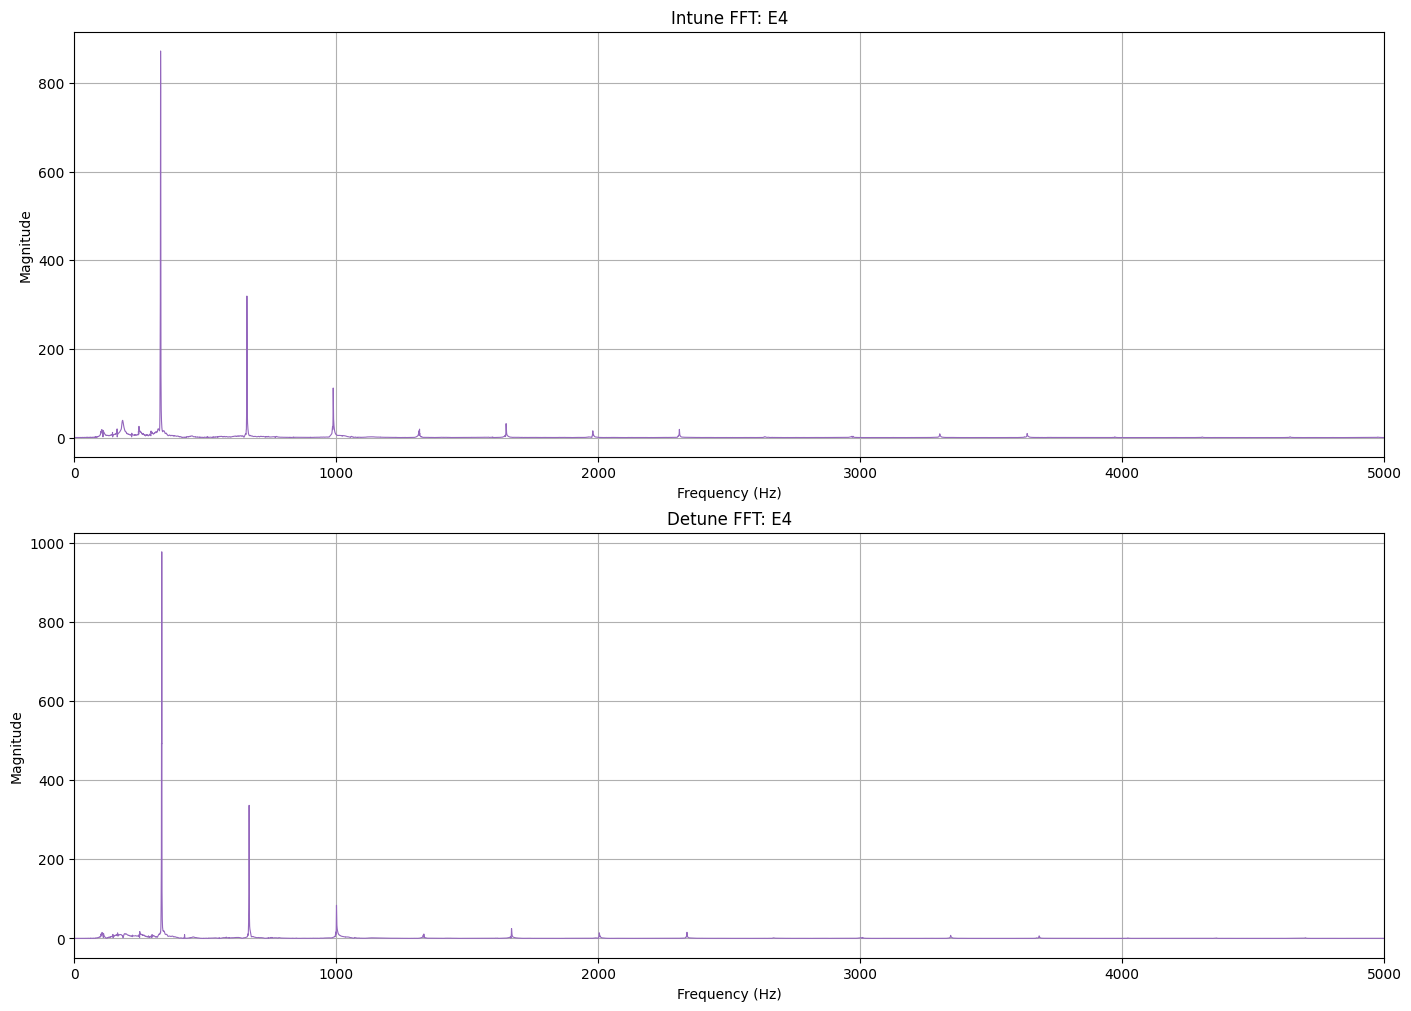

In [8]:
def plot_fft(signal, sr, ax, title):
    n = len(signal)
    fft_result = np.fft.rfft(signal)
    freqs = np.fft.rfftfreq(n, 1 / sr)
    magnitude = np.abs(fft_result)
    ax.plot(freqs, magnitude, color='tab:purple', linewidth=0.8)
    ax.set_xlim(0, 5000)
    ax.set_title(title)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('Magnitude')

note = 'E4'
sample_intune = intune_files[intune_files['note_folder'] == note].iloc[0] if note in intune_files['note_folder'].values else None
sample_detune = detune_files[detune_files['note_folder'] == note].iloc[0] if note in detune_files['note_folder'].values else None

fig, axes = plt.subplots(2, 1, figsize=(14, 10), constrained_layout=True)
if sample_intune is not None:
    signal_i, sr_i = load_audio(sample_intune['path'])
    plot_fft(signal_i, sr_i, axes[0], f'Intune FFT: {note}')
else:
    axes[0].text(0.5, 0.5, 'Intune sample missing', ha='center', va='center')
    axes[0].set_axis_off()

if sample_detune is not None:
    signal_d, sr_d = load_audio(sample_detune['path'])
    plot_fft(signal_d, sr_d, axes[1], f'Detune FFT: {note}')
else:
    axes[1].text(0.5, 0.5, 'Detune sample missing', ha='center', va='center')
    axes[1].set_axis_off()

plt.show()

## 4. Compute and Plot Spectrograms

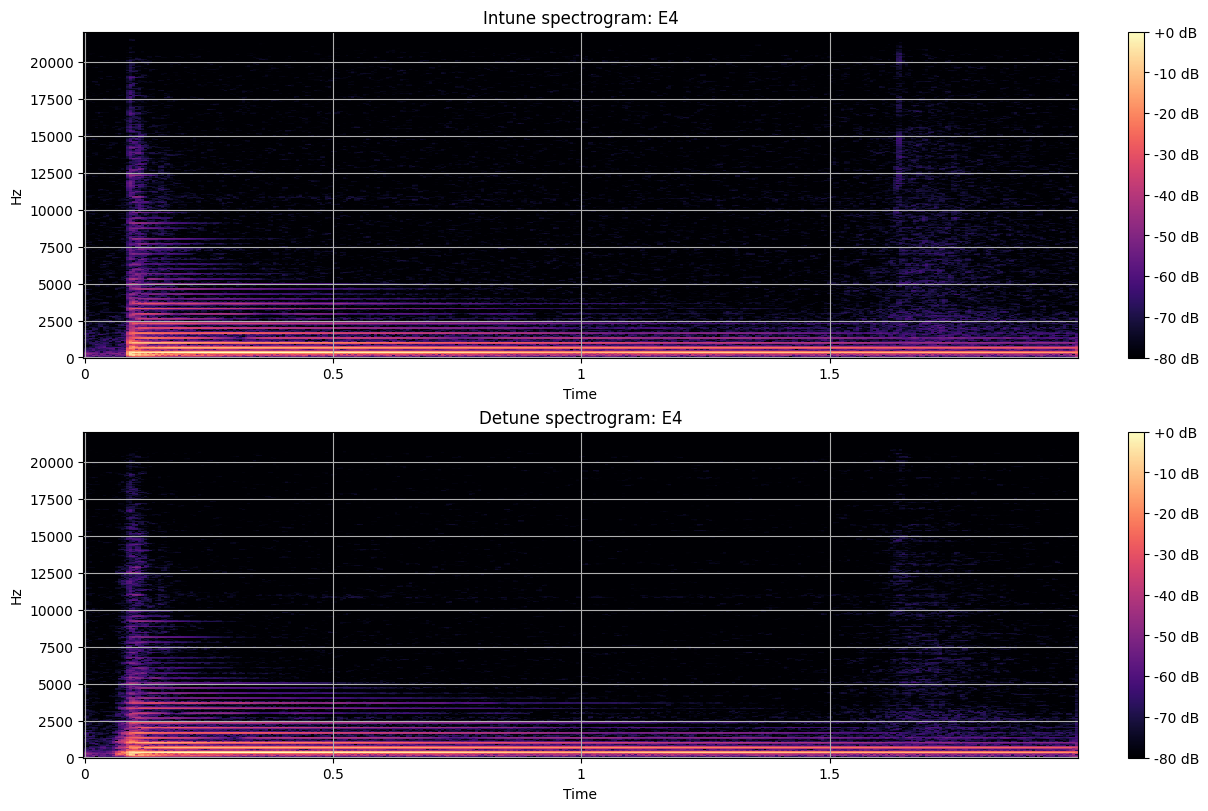

In [9]:
def plot_spectrogram(signal, sr, ax, title):
    S = np.abs(librosa.stft(signal, n_fft=1024, hop_length=256))
    S_db = librosa.amplitude_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='hz', cmap='magma', ax=ax)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')

note = 'E4'
sample_intune = intune_files[intune_files['note_folder'] == note].iloc[0] if note in intune_files['note_folder'].values else None
sample_detune = detune_files[detune_files['note_folder'] == note].iloc[0] if note in detune_files['note_folder'].values else None

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
if sample_intune is not None:
    signal_i, sr_i = load_audio(sample_intune['path'])
    plot_spectrogram(signal_i, sr_i, axes[0], f'Intune spectrogram: {note}')
else:
    axes[0].text(0.5, 0.5, 'Intune sample missing', ha='center', va='center')
    axes[0].set_axis_off()

if sample_detune is not None:
    signal_d, sr_d = load_audio(sample_detune['path'])
    plot_spectrogram(signal_d, sr_d, axes[1], f'Detune spectrogram: {note}')
else:
    axes[1].text(0.5, 0.5, 'Detune sample missing', ha='center', va='center')
    axes[1].set_axis_off()

plt.show()

## 5. Extract and Visualize MFCC Features

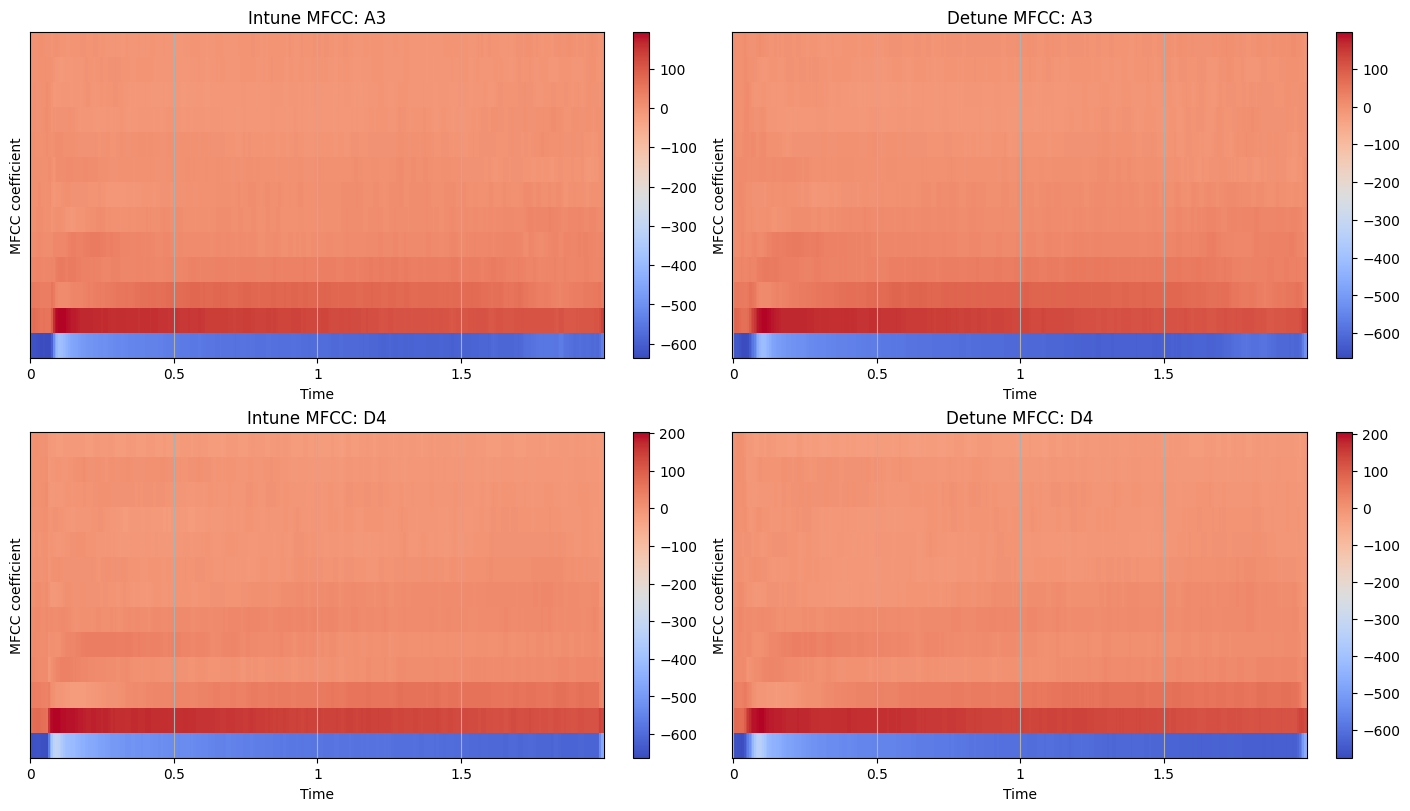

In [10]:
def plot_mfcc(signal, sr, ax, title):
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13, hop_length=256)
    img = librosa.display.specshow(mfcc, x_axis='time', sr=sr, hop_length=256, cmap='coolwarm', ax=ax)
    ax.set_title(title)
    ax.set_ylabel('MFCC coefficient')
    fig.colorbar(img, ax=ax)

notes_to_plot = ['A3', 'D4']
fig, axes = plt.subplots(len(notes_to_plot), 2, figsize=(14, 4 * len(notes_to_plot)), constrained_layout=True)
for row, note in enumerate(notes_to_plot):
    intune_sample = intune_files[intune_files['note_folder'] == note].iloc[0] if note in intune_files['note_folder'].values else None
    detune_sample = detune_files[detune_files['note_folder'] == note].iloc[0] if note in detune_files['note_folder'].values else None

    if intune_sample is not None:
        signal_i, sr_i = load_audio(intune_sample['path'])
        plot_mfcc(signal_i, sr_i, axes[row, 0], f'Intune MFCC: {note}')
    else:
        axes[row, 0].text(0.5, 0.5, 'Missing intune MFCC', ha='center', va='center')
        axes[row, 0].set_axis_off()

    if detune_sample is not None:
        signal_d, sr_d = load_audio(detune_sample['path'])
        plot_mfcc(signal_d, sr_d, axes[row, 1], f'Detune MFCC: {note}')
    else:
        axes[row, 1].text(0.5, 0.5, 'Missing detune MFCC', ha='center', va='center')
        axes[row, 1].set_axis_off()

plt.show()

## 6. Analyze Duration, Sample Rate, and Amplitude Statistics

Intune stats snapshot:


,root,note_folder,file_name,path,file_note,technique,instance,duration_s,sample_rate,peak_amplitude,rms_energy,zero_crossing_rate
0,intune,A2,A2_f_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,A2_f_1,None,None,2.0,44100.0,0.258362,0.050440,0.009002
1,intune,A2,A2_f_2.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,A2_f_2,None,None,2.0,44100.0,0.316315,0.054570,0.009218
2,intune,A2,A2_p_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,A2_p_1,None,None,2.0,44100.0,0.232025,0.039160,0.013322
3,intune,A2,A2_p_2.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,A2_p_2,None,None,2.0,44100.0,0.211548,0.037660,0.019263
4,intune,A3,A3_f_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,A3_f_1,None,None,2.0,44100.0,0.181824,0.035993,0.011769


Detune stats snapshot:


,root,note_folder,file_name,path,file_note,technique,instance,duration_s,sample_rate,peak_amplitude,rms_energy,zero_crossing_rate
0,detune,A2,detuned_A2_f_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,detuned_A2_f_1,None,None,2.0,44100.0,0.211975,0.036153,0.010850
1,detune,A2,detuned_A2_f_2.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,detuned_A2_f_2,None,None,2.0,44100.0,0.213074,0.033023,0.008991
2,detune,A2,detuned_A2_p_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,detuned_A2_p_1,None,None,2.0,44100.0,0.196564,0.028698,0.014841
3,detune,A2,detuned_A2_p_2.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,detuned_A2_p_2,None,None,2.0,44100.0,0.160065,0.030128,0.014524
4,detune,A3,detuned_A3_f_1.wav,/kaggle/input/datasets/heysiri0/acoustic-guita...,detuned_A3_f_1,None,None,2.0,44100.0,0.118652,0.028591,0.010850


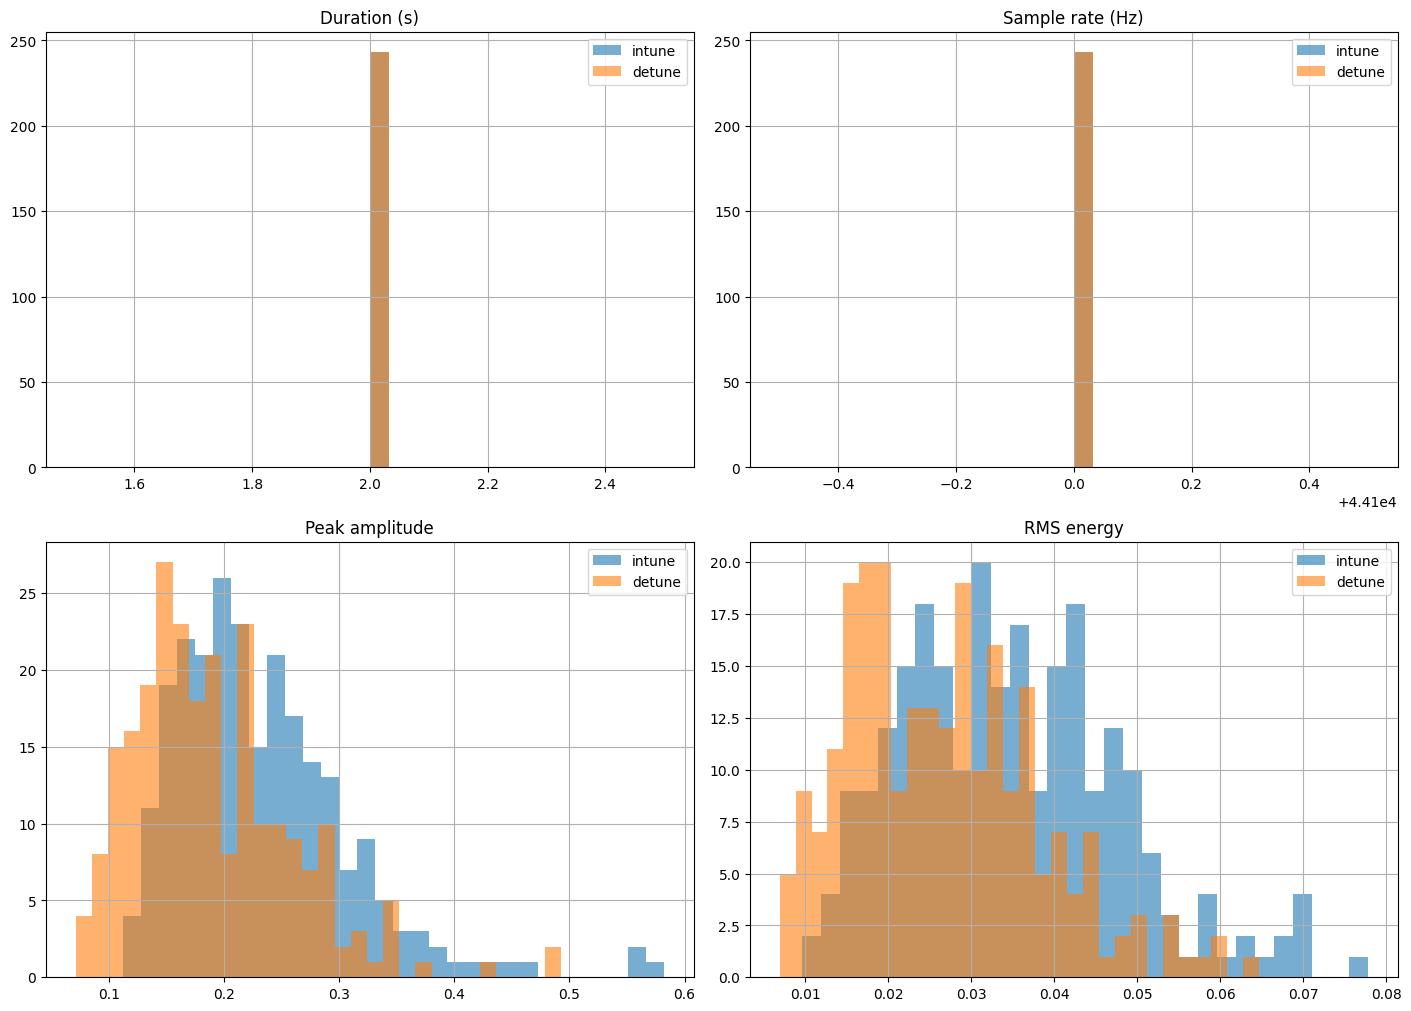

In [11]:
def compute_audio_stats(row):
    path = row['path']
    signal, sr = librosa.load(path, sr=None, mono=True)
    duration = len(signal) / sr
    peak = np.max(np.abs(signal))
    rms = np.sqrt(np.mean(signal ** 2))
    zcr = np.mean(librosa.zero_crossings(signal, pad=False))
    return pd.Series({
        'duration_s': duration,
        'sample_rate': sr,
        'peak_amplitude': peak,
        'rms_energy': rms,
        'zero_crossing_rate': zcr
    })

stats_intune = intune_files.copy()
stats_detune = detune_files.copy()

stats_intune = stats_intune.join(stats_intune.apply(compute_audio_stats, axis=1))
stats_detune = stats_detune.join(stats_detune.apply(compute_audio_stats, axis=1))

print('Intune stats snapshot:')
display(stats_intune.head())
print('Detune stats snapshot:')
display(stats_detune.head())

fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
stats_combined = pd.concat([stats_intune.assign(group='intune'), stats_detune.assign(group='detune')])
for ax, metric, title in [
    (axs[0, 0], 'duration_s', 'Duration (s)'),
    (axs[0, 1], 'sample_rate', 'Sample rate (Hz)'),
    (axs[1, 0], 'peak_amplitude', 'Peak amplitude'),
    (axs[1, 1], 'rms_energy', 'RMS energy')
]:
    for group, color in [('intune', 'tab:blue'), ('detune', 'tab:orange')]:
        subset = stats_combined[stats_combined['group'] == group]
        ax.hist(subset[metric], bins=30, alpha=0.6, label=group, color=color)
    ax.set_title(title)
    ax.legend()

plt.show()

## 7. Compare Intune vs Detune Note Distributions

,note_folder,duration_diff,peak_diff,rms_diff,zcr_diff
0,A2,0.0,-0.046387,-0.014286,0.001848
1,A2,0.0,-0.045288,-0.017417,-0.000011
2,A2,0.0,-0.061798,-0.021741,0.005839
3,A2,0.0,-0.098297,-0.020311,0.005522
4,A2,0.0,-0.104340,-0.018417,0.001633
5,A2,0.0,-0.103241,-0.021548,-0.000227
6,A2,0.0,-0.119751,-0.025872,0.005624
7,A2,0.0,-0.156250,-0.024442,0.005306
8,A2,0.0,-0.020050,-0.003007,-0.002472
9,A2,0.0,-0.018951,-0.006138,-0.004331


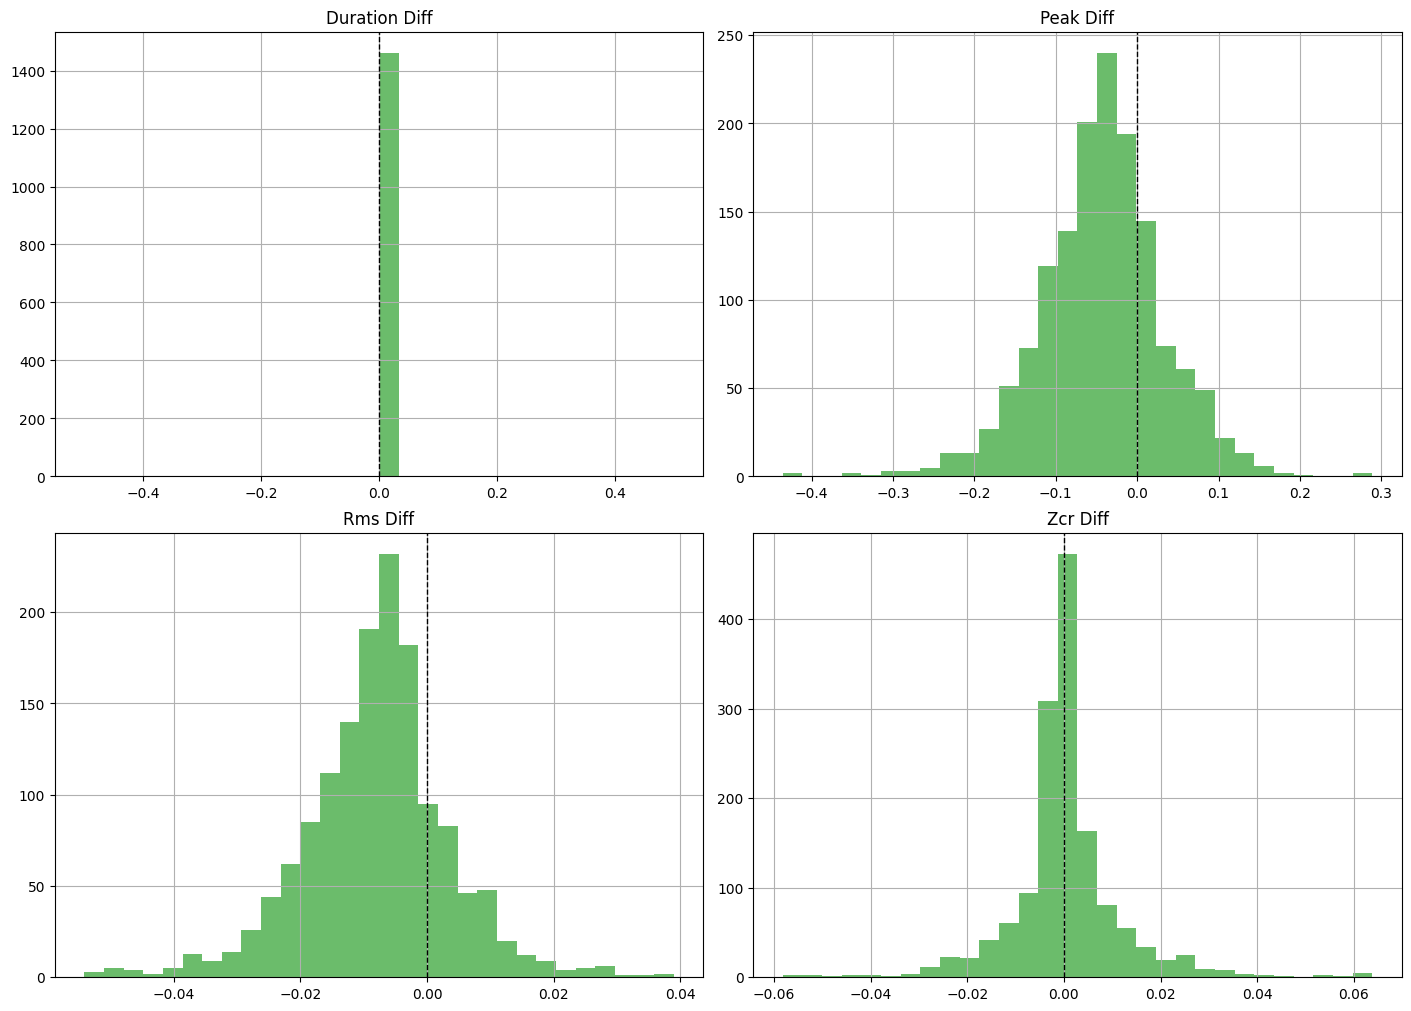

In [12]:
paired = pd.merge(
    stats_intune[['note_folder', 'duration_s', 'peak_amplitude', 'rms_energy', 'zero_crossing_rate']],
    stats_detune[['note_folder', 'duration_s', 'peak_amplitude', 'rms_energy', 'zero_crossing_rate']],
    on='note_folder',
    suffixes=('_intune', '_detune')
)

paired['duration_diff'] = paired['duration_s_detune'] - paired['duration_s_intune']
paired['peak_diff'] = paired['peak_amplitude_detune'] - paired['peak_amplitude_intune']
paired['rms_diff'] = paired['rms_energy_detune'] - paired['rms_energy_intune']
paired['zcr_diff'] = paired['zero_crossing_rate_detune'] - paired['zero_crossing_rate_intune']

display(paired[['note_folder', 'duration_diff', 'peak_diff', 'rms_diff', 'zcr_diff']].head(10))

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, metric in zip(axes.ravel(), ['duration_diff', 'peak_diff', 'rms_diff', 'zcr_diff']):
    ax.hist(paired[metric], bins=30, color='tab:green', alpha=0.7)
    ax.set_title(metric.replace('_', ' ').title())
    ax.axvline(0, color='black', linestyle='--', linewidth=1)

plt.show()

## 8. Aggregate Pitch and Octave Summaries

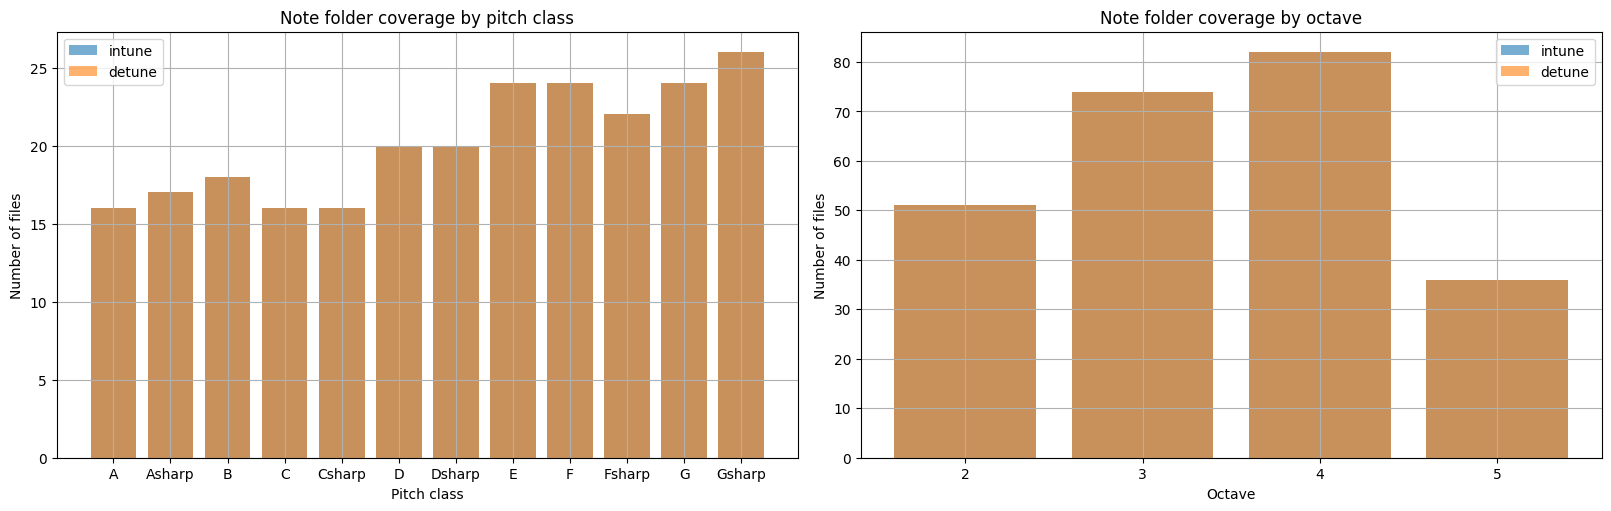

In [13]:
def parse_note_folder(note_folder):
    pitch = ''.join([c for c in note_folder if not c.isdigit()])
    octave = ''.join([c for c in note_folder if c.isdigit()])
    return pitch, int(octave) if octave.isdigit() else None

for df in [intune_files, detune_files]:
    df[['pitch', 'octave']] = df['note_folder'].apply(lambda x: pd.Series(parse_note_folder(x)))

coverage = pd.concat([intune_files.assign(group='intune'), detune_files.assign(group='detune')])
pitch_counts = coverage.groupby(['group', 'pitch']).size().reset_index(name='count')
octave_counts = coverage.groupby(['group', 'octave']).size().reset_index(name='count')

fig, axs = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
for group, color in [('intune', 'tab:blue'), ('detune', 'tab:orange')]:
    subset = pitch_counts[pitch_counts['group'] == group]
    axs[0].bar(subset['pitch'], subset['count'], alpha=0.6, label=group, color=color)
axs[0].set_title('Note folder coverage by pitch class')
axs[0].set_xlabel('Pitch class')
axs[0].set_ylabel('Number of files')
axs[0].legend()

for group, color in [('intune', 'tab:blue'), ('detune', 'tab:orange')]:
    subset = octave_counts[octave_counts['group'] == group]
    axs[1].bar(subset['octave'].astype(str), subset['count'], alpha=0.6, label=group, color=color)
axs[1].set_title('Note folder coverage by octave')
axs[1].set_xlabel('Octave')
axs[1].set_ylabel('Number of files')
axs[1].legend()

plt.show()

## 9. PCA and t-SNE Embeddings of Audio Features

Explained variance ratio (PCA first 2 components):
[0.3756 0.1923]


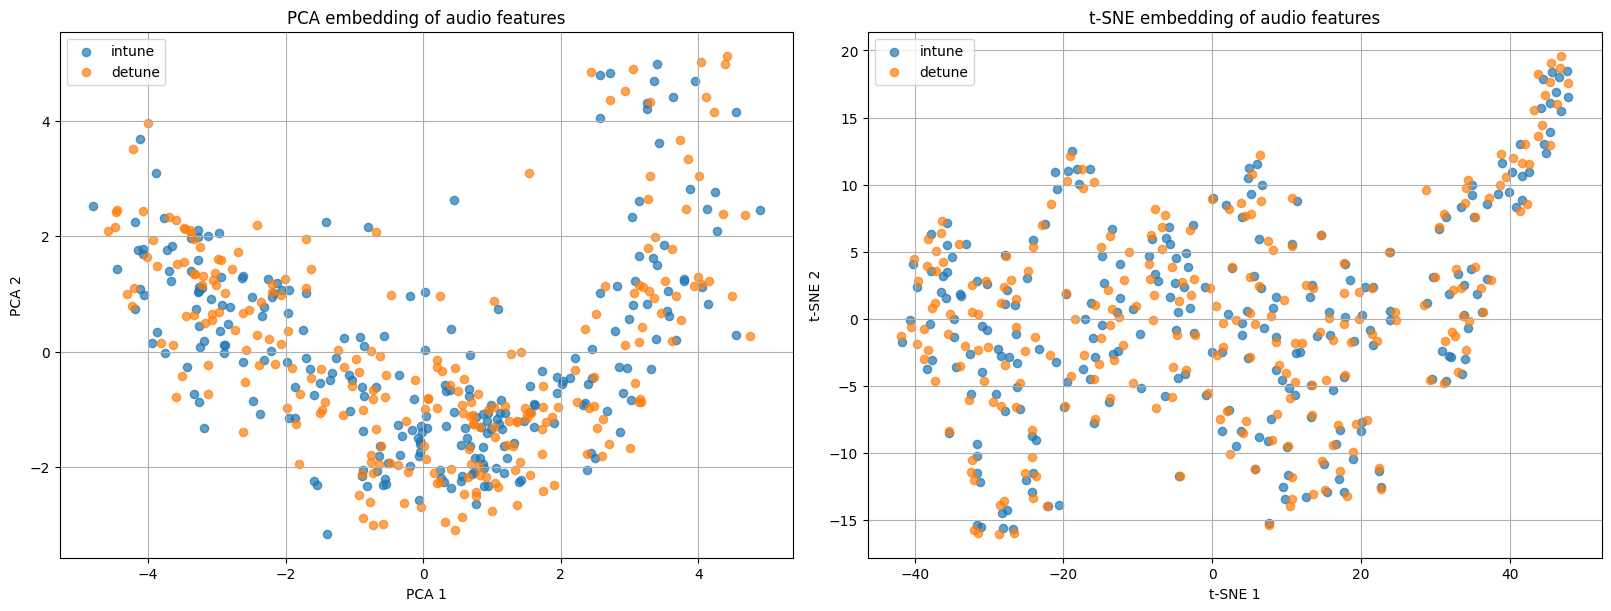

In [14]:
def extract_feature_vector(path):
    signal, sr = load_audio(path)
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13, hop_length=256)
    mfcc_mean = mfcc.mean(axis=1)
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)[0].mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr)[0].mean()
    zcr = librosa.feature.zero_crossing_rate(y=signal)[0].mean()
    return np.concatenate([mfcc_mean, [centroid, bandwidth, zcr]])

feature_records = []
combined = pd.concat([
    intune_files.assign(group='intune'),
    detune_files.assign(group='detune')
]).reset_index(drop=True)

for idx, row in combined.iterrows():
    features = extract_feature_vector(row['path'])
    record = {
        'path': row['path'],
        'group': row['group'],
        'note_folder': row['note_folder'],
        'file_name': row['file_name']
    }
    record.update({f'feat_{i+1}': value for i, value in enumerate(features)})
    feature_records.append(record)

features_df = pd.DataFrame(feature_records)
feature_columns = [c for c in features_df.columns if c.startswith('feat_')]
X = StandardScaler().fit_transform(features_df[feature_columns])

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X)
features_df['pca_1'] = pca_result[:, 0]
features_df['pca_2'] = pca_result[:, 1]

print('Explained variance ratio (PCA first 2 components):')
print(np.round(pca.explained_variance_ratio_, 4))

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X)
features_df['tsne_1'] = tsne_result[:, 0]
features_df['tsne_2'] = tsne_result[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for group, color in [('intune', 'tab:blue'), ('detune', 'tab:orange')]:
    subset = features_df[features_df['group'] == group]
    axes[0].scatter(subset['pca_1'], subset['pca_2'], label=group, alpha=0.7, s=35, color=color)
    axes[1].scatter(subset['tsne_1'], subset['tsne_2'], label=group, alpha=0.7, s=35, color=color)

axes[0].set_title('PCA embedding of audio features')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

axes[1].set_title('t-SNE embedding of audio features')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend()

plt.show()